In [17]:
#Data Loaded

#Load & Inspect Data
# ===============================
# STEP 0: Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ===============================
# STEP 1: Load Data
# ===============================
df = pd.read_csv('enhanced_health_insurance_claims.csv',nrows=1000)

print("First 5 rows:")
print(df.head())

# ===============================
# STEP 2: Basic Info
# ===============================
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


First 5 rows:
                                ClaimID                             PatientID  \
0  10944daf-f7d5-4e1d-8216-72ffa609fe41  8552381d-7960-4f64-b190-b20b8ada00a1   
1  fcbebb25-fc24-4c0f-a966-749edcf83fb1  327f43ad-e3bd-4473-a9ed-46483a0a156f   
2  9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1  6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0   
3  a06273ed-44bb-452b-bbad-8618de080494  5d58e183-701e-406c-a8c6-5b73cac5e912   
4  f702a717-254b-4cff-a0c7-8395db2f6616  8a8ebdf6-3af0-4f14-82f3-37b937c3d270   

                             ProviderID  ClaimAmount  ClaimDate DiagnosisCode  \
0  4a4cb19c-4863-41cf-84b0-c2b21aace988      3807.95   6/7/2024         yy006   
1  422e02dd-c1fd-43dd-8af4-0c3523f997b1      9512.07  5/30/2023         tD052   
2  f7733b3f-0980-47b5-a7a0-ee390869355b      7346.74  9/27/2022         zx832   
3  f7a04581-de96-44ee-b773-8adac02baa59      6026.72  6/25/2023         kr421   
4  b80b9e77-97f0-47d7-b561-19f9658a7bdf      1644.58  7/24/2023         LZ261   

  ProcedureC

In [18]:
# ===============================
# DATA CLEANING
# ===============================

print("Missing values BEFORE cleaning:")
print(df.isnull().sum().sort_values(ascending=False))

# Drop duplicates
print("\nDuplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

# -------------------------------
# Fill numeric columns with median
# -------------------------------
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# -------------------------------
# Fill categorical columns with mode
# -------------------------------
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -------------------------------
# Final check
# -------------------------------
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values BEFORE cleaning:
ClaimID                    0
ProviderSpecialty          0
ClaimType                  0
ProviderLocation           0
PatientEmploymentStatus    0
PatientMaritalStatus       0
PatientIncome              0
ClaimStatus                0
PatientGender              0
PatientID                  0
PatientAge                 0
ProcedureCode              0
DiagnosisCode              0
ClaimDate                  0
ClaimAmount                0
ProviderID                 0
ClaimSubmissionMethod      0
dtype: int64

Duplicates before: 0
Duplicates after: 0

Missing values AFTER cleaning:
ClaimID                    0
ProviderSpecialty          0
ClaimType                  0
ProviderLocation           0
PatientEmploymentStatus    0
PatientMaritalStatus       0
PatientIncome              0
ClaimStatus                0
PatientGender              0
PatientID                  0
PatientAge                 0
ProcedureCode              0
DiagnosisCode              0
ClaimDate  

Value counts: ClaimStatus
Approved    348
Pending     343
Denied      309
Name: count, dtype: int64

Percentage distribution:
ClaimStatus
Approved    34.8
Pending     34.3
Denied      30.9
Name: count, dtype: float64


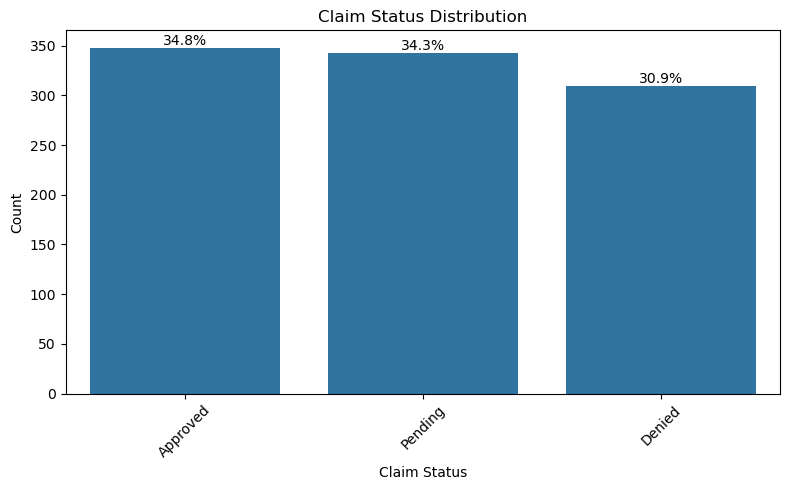

In [19]:

# ===============================
# TARGET DISTRIBUTION ANALYSIS
# ===============================

target_column = "ClaimStatus"

counts = df[target_column].value_counts()
percentages = (counts / counts.sum()) * 100

print("Value counts:", counts)

print("\nPercentage distribution:")
print(percentages)

# Prepare DataFrame for seaborn
plot_df = counts.reset_index()
plot_df.columns = [target_column, "Count"]

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x=target_column, y="Count")

# Add percentage labels 
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{percentages.iloc[i]:.1f}%", 
             ha='center', va='bottom')

plt.title("Claim Status Distribution")
plt.xlabel("Claim Status")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


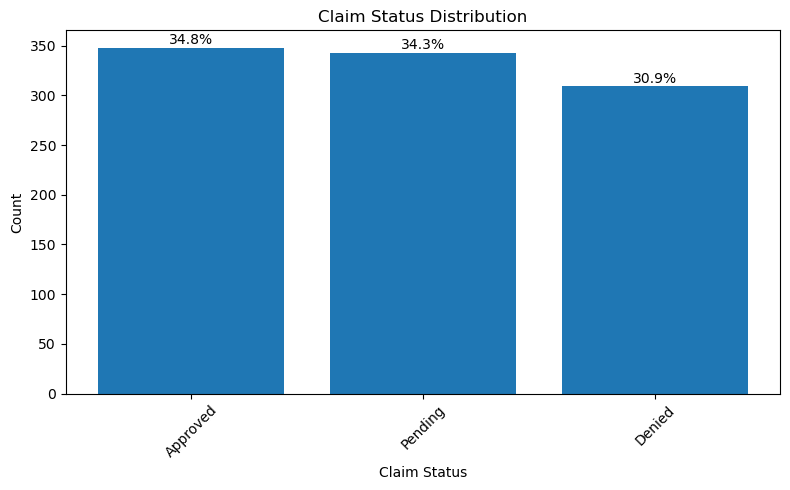

In [20]:
plt.figure(figsize=(8,5))

# Plot bars
plt.bar(counts.index.astype(str), counts.values)

# Add percentage labels
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01,
             f"{(v / counts.sum())*100:.1f}%",
             ha='center')

plt.title("Claim Status Distribution")
plt.xlabel("Claim Status")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

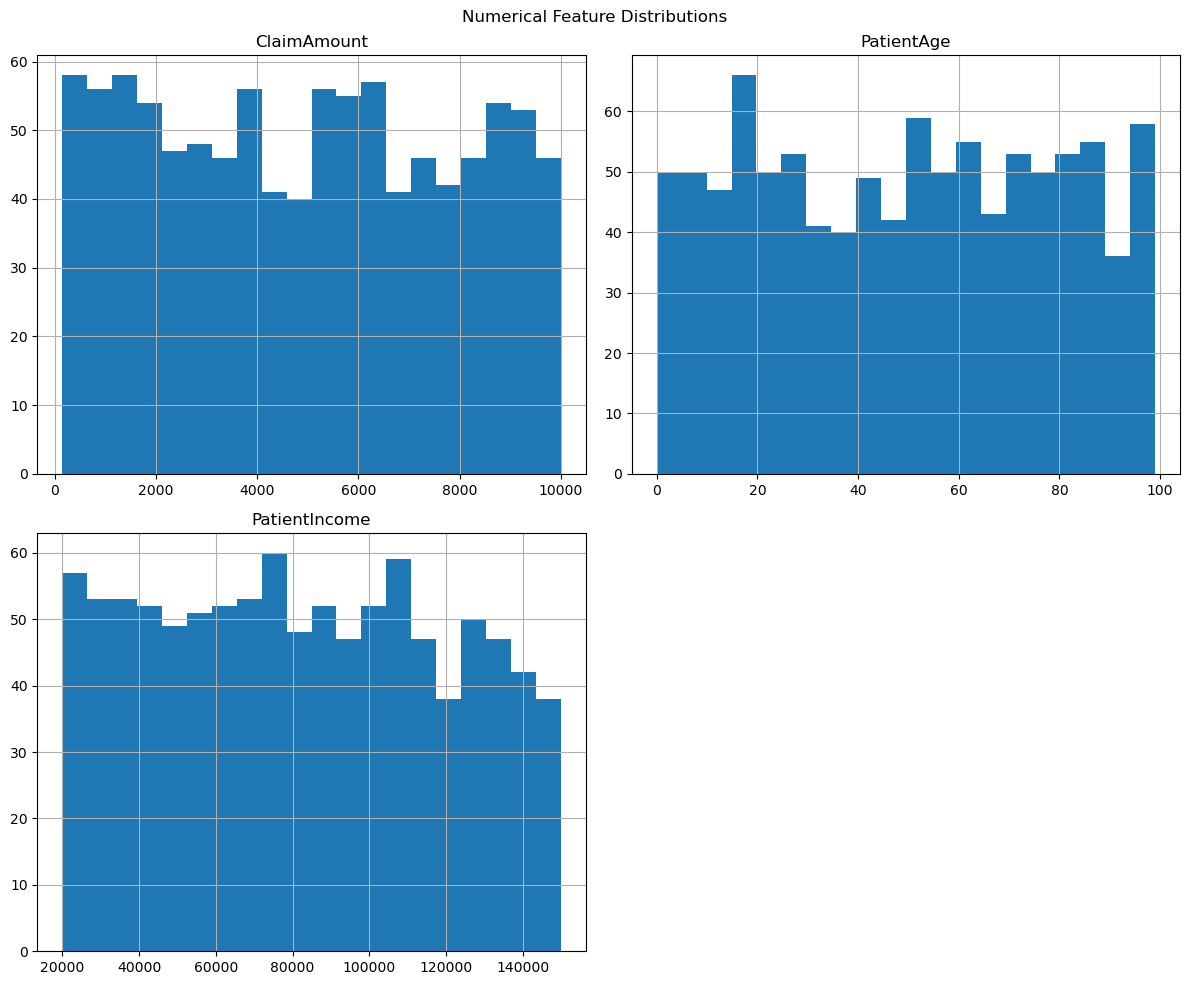

In [21]:
#EDA -Numerical Features Distribution
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(12,10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

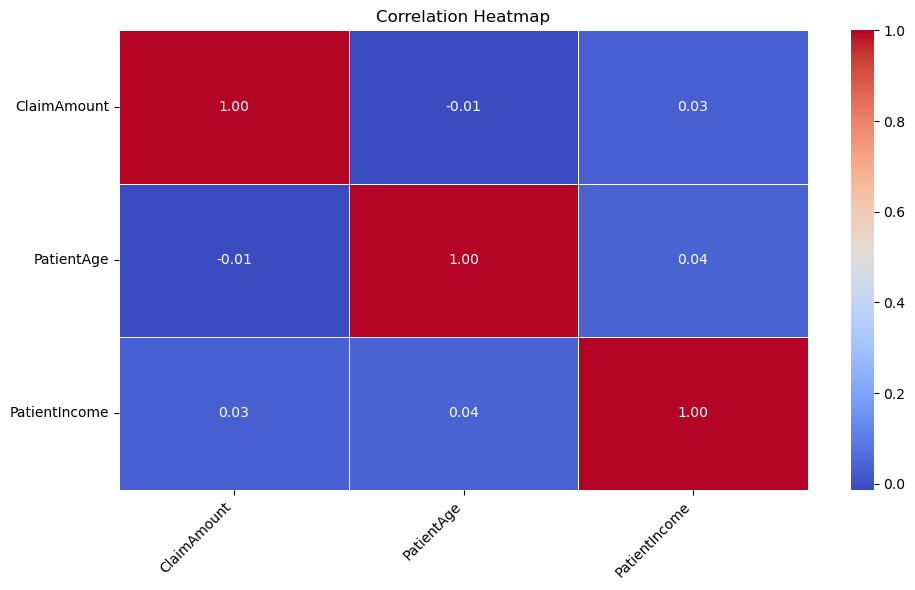

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

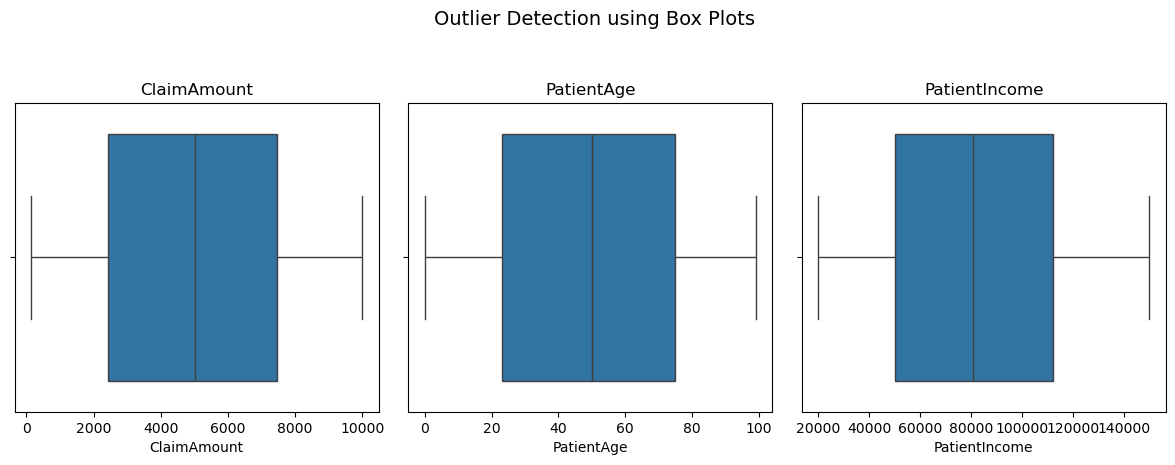

In [23]:
# ===============================
# BOX PLOTS - OUTLIER DETECTION
# ===============================

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols[:6]):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.xlabel(col)

plt.suptitle("Outlier Detection using Box Plots", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

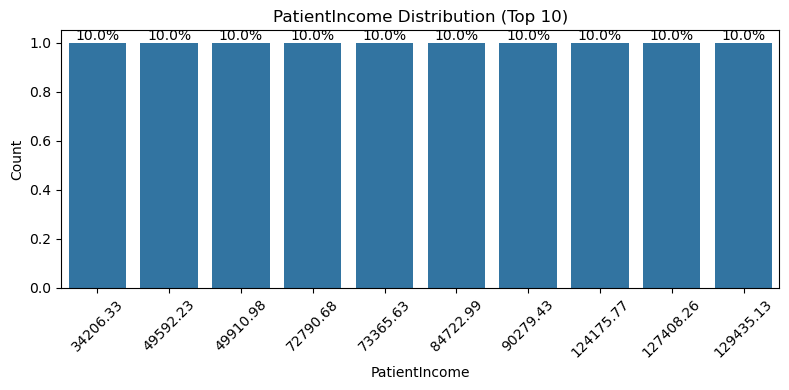

In [24]:
counts = df[col].value_counts().head(10)

plt.figure(figsize=(8,4))

sns.barplot(x=counts.index, y=counts.values)

total = counts.sum()
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{(v/total)*100:.1f}%", ha='center', va='bottom')

plt.title(f"{col} Distribution (Top 10)")
plt.xlabel(col)
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [25]:
# ===============================
# DROP ID COLUMNS FIRST
# ===============================
id_cols = ['ClaimID', 'PatientID', 'ProviderID']
df = df.drop(columns=[col for col in id_cols if col in df.columns], errors='ignore')

# ===============================
# FEATURE ENGINEERING
# ===============================
if 'ClaimAmount' in df.columns and 'PatientAge' in df.columns:
    df['ClaimPerAge'] = df['ClaimAmount'] / (df['PatientAge'] + 1)

# ===============================
# ENCODE TARGET
# ===============================
from sklearn.preprocessing import LabelEncoder

target_column = "ClaimStatus"
df[target_column] = LabelEncoder().fit_transform(df[target_column].astype(str))

# ===============================
# ONE-HOT ENCODING (SAFE NOW)
# ===============================
df = pd.get_dummies(df, drop_first=True)

Accuracy: 0.41

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.53      0.47        70
           1       0.31      0.18      0.23        62
           2       0.43      0.50      0.46        68

    accuracy                           0.41       200
   macro avg       0.39      0.40      0.39       200
weighted avg       0.39      0.41      0.39       200



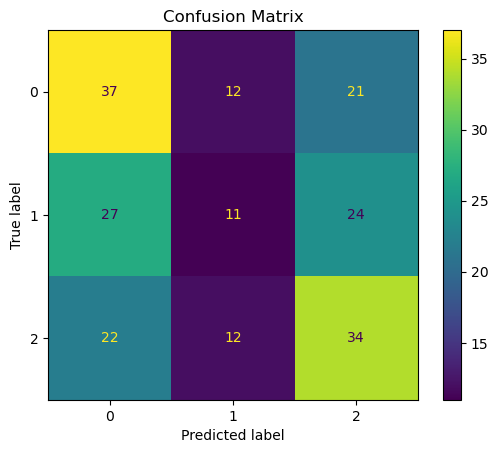

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# ===============================
# COPY DATA (SAFE PRACTICE)
# ===============================
df = df.copy()

# ===============================
# BASIC CLEANING
# ===============================

# Remove duplicates
df = df.drop_duplicates()

# Fill missing numeric values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ===============================
# FEATURE ENGINEERING
# ===============================
if 'ClaimAmount' in df.columns and 'PatientAge' in df.columns:
    df['ClaimPerAge'] = df['ClaimAmount'] / (df['PatientAge'] + 1)

# ===============================
# DROP ID COLUMNS
# ===============================
id_cols = ['ClaimID', 'PatientID', 'ProviderID']
df = df.drop(columns=[col for col in id_cols if col in df.columns], errors='ignore')

# ===============================
# DEFINE TARGET
# ===============================
target_column = "ClaimStatus"

# ===============================
# SPLIT FEATURES & TARGET
# ===============================
X = df.drop(columns=[target_column])
y = df[target_column]

# ===============================
# ENCODE TARGET
# ===============================
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# ===============================
# ONE-HOT ENCODE FEATURES (IMPORTANT)
# ===============================
X = pd.get_dummies(X, drop_first=True)

# ===============================
# TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# FEATURE SCALING
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# MODEL TRAINING
# ===============================
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# ===============================
# PREDICTIONS
# ===============================
y_pred = model.predict(X_test)

# ===============================
# EVALUATION
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()


In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.395

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.49      0.41        70
           1       0.47      0.11      0.18        62
           2       0.42      0.56      0.48        68

    accuracy                           0.40       200
   macro avg       0.42      0.39      0.36       200
weighted avg       0.41      0.40      0.36       200



Accuracy: 0.395

Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.40      0.43        70
           1       0.34      0.18      0.23        62
           2       0.37      0.59      0.46        68

    accuracy                           0.40       200
   macro avg       0.39      0.39      0.37       200
weighted avg       0.39      0.40      0.38       200



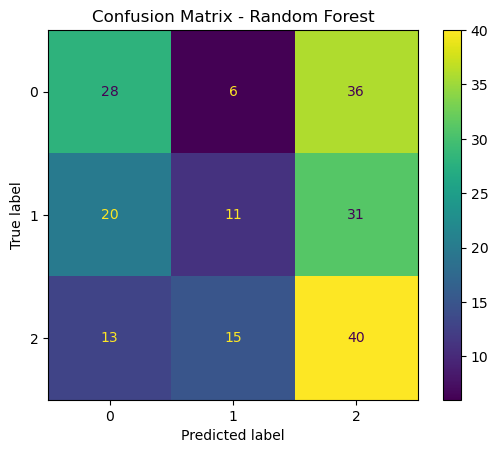

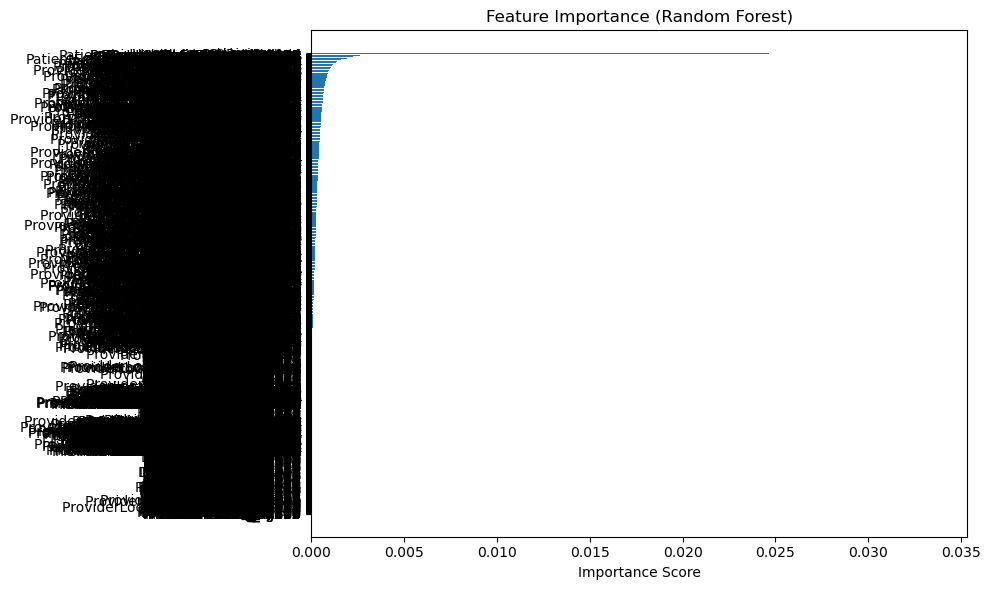

In [28]:
# ===============================
# RANDOM FOREST - CAPSTONE MODEL 
# ===============================

# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ===============================
# COPY DATA SAFELY
# ===============================
df = df.copy()

# ===============================
# BASIC CLEANING
# ===============================

# Remove duplicates
df = df.drop_duplicates()

# Fill missing numeric values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ===============================
# FEATURE ENGINEERING
# ===============================
if 'ClaimAmount' in df.columns and 'PatientAge' in df.columns:
    df['ClaimPerAge'] = df['ClaimAmount'] / (df['PatientAge'] + 1)

# ===============================
# DROP ID COLUMNS
# ===============================
id_cols = ['ClaimID', 'PatientID', 'ProviderID']
df = df.drop(columns=[col for col in id_cols if col in df.columns], errors='ignore')

# ===============================
# DEFINE TARGET
# ===============================
target_column = "ClaimStatus"

# ===============================
# SPLIT FEATURES AND TARGET
# ===============================
X = df.drop(columns=[target_column])
y = df[target_column]

# ===============================
# ENCODE TARGET
# ===============================
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# ===============================
# ONE-HOT ENCODE FEATURES (BEST PRACTICE)
# ===============================
X = pd.get_dummies(X, drop_first=True)

# ===============================
# TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Save feature names (important for interpretation)
feature_names = X.columns

# ===============================
# MODEL TRAINING
# ===============================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# ===============================
# PREDICTIONS
# ===============================
y_pred = model.predict(X_test)

# ===============================
# EVALUATION
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ===============================
# FEATURE IMPORTANCE
# ===============================
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

# Encode target for correlation analysis
le_corr = LabelEncoder()
df_corr["ClaimStatus"] = le_corr.fit_transform(df_corr["ClaimStatus"])

# Correlation with target
corr_series = df_corr.corr(numeric_only=True)["ClaimStatus"]

# Remove self-correlation
corr_series = corr_series.drop("ClaimStatus")

# Sort results
print("Feature correlation with ClaimStatus:")
print(corr_series.sort_values(ascending=False))

Feature correlation with ClaimStatus:
ProviderSpecialty_Pediatrics    0.093394
ClaimDate_6/7/2024              0.076619
ClaimDate_11/24/2023            0.066321
ClaimDate_8/14/2023             0.066321
ClaimDate_7/20/2023             0.066321
                                  ...   
ClaimDate_12/6/2022            -0.056797
ClaimDate_3/4/2024             -0.065661
ClaimDate_1/5/2023             -0.065661
ProviderSpecialty_Neurology    -0.070842
ClaimDate_1/3/2024             -0.075856
Name: ClaimStatus, Length: 3534, dtype: float64


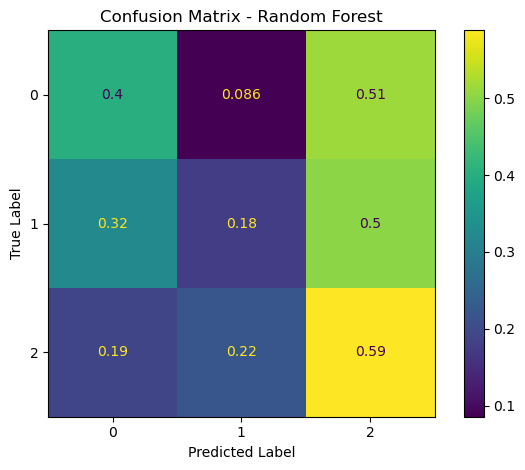

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    normalize='true'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

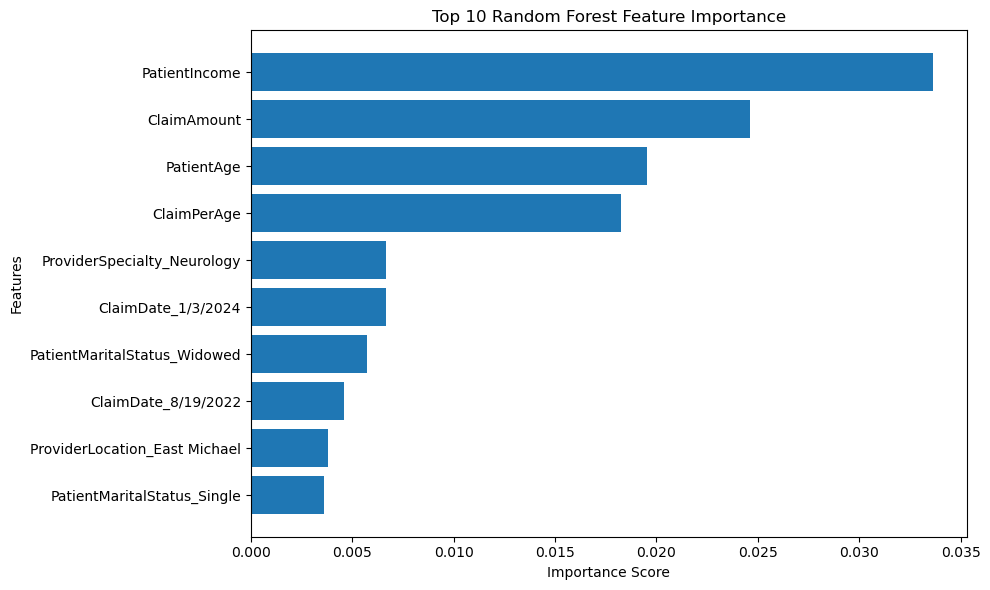

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ===============================

# Get feature importance from trained model
importances = model.feature_importances_

# Use saved feature names from training step
features = feature_names

# Create DataFrame
feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

# ===============================
# OPTIONAL: KEEP TOP FEATURES ONLY (recommended)
# ===============================
top_n = 10
feat_df_top = feat_df.tail(top_n)

# ===============================
# PLOT FEATURE IMPORTANCE
# ===============================
plt.figure(figsize=(10,6))

plt.barh(feat_df_top["Feature"], feat_df_top["Importance"])

plt.title(f"Top {top_n} Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

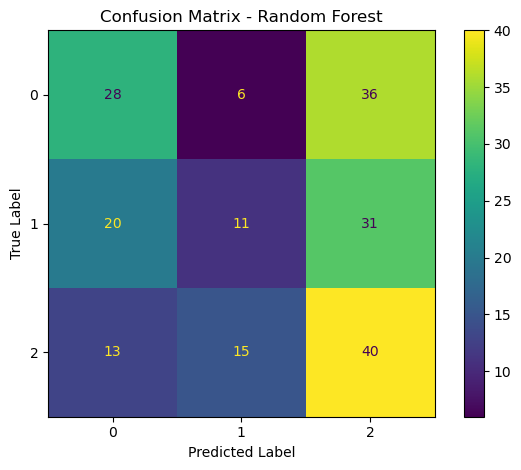

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ===============================
# CONFUSION MATRIX
# ===============================
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

###### 